# Atividade de vendas no Brasil

In [1073]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
arquivo = "C:/.Vscode/ufrj-analytica-training/data/vendas_brasil_1.csv"
df = pd.read_csv(arquivo)

## Entregavel 1 - NumPy

### A) Criando Arrays

In [1074]:
preco_un = np.array(df["preco_unitario"])
custo_un = np.array(df["custo_unitario"])
qntd = np.array(df["quantidade"])
desconto = np.array(df["desconto_pct"])
rec_tot = np.array(df["receita_total"])
frete = np.array(df["frete"])
print(df.__len__())

37617


### B) Cálculos com operações vetorizadas

In [1075]:
vlr_bruto = preco_un * qntd
vlr_desconto = vlr_bruto * (desconto/100)
custo_tot = custo_un * qntd
lucro_est = vlr_bruto - vlr_desconto - custo_tot
print(lucro_est.max())
print(lucro_est.min())

8577.65335
-1540.1457499999979


### C) Máscaras Booleanas

In [1076]:
masc1 = rec_tot>rec_tot.mean() #Receita acima da média
masc2 = lucro_est < 0 #Prejuízo
masc3 = desconto > 25 #Descontos maior que 25% são considerados altos
masc4 = lucro_est > lucro_est.mean()

print("Quantidade de vendas com receitas acima da média:",rec_tot[masc1].size)
print("Quantidade de vendas com prejuízo:",lucro_est[masc2].size)
print("Quantidade de vendas com desconto alto:",desconto[masc3].size)
print("Quantidade de vendas com lucro maior que a média",lucro_est[masc4].size)


Quantidade de vendas com receitas acima da média: 9236
Quantidade de vendas com prejuízo: 2857
Quantidade de vendas com desconto alto: 2304
Quantidade de vendas com lucro maior que a média 8988


### D) Agregações

In [1077]:
rec_media = rec_tot.mean()
rec_max = rec_tot.max()
rec_min = rec_tot.min()
lucro_medio = lucro_est.mean()
lucro_perto_media = lucro_est[(lucro_est < lucro_medio * (3/2)) & (lucro_est > lucro_medio / 2)]
qntd_preju = lucro_est[masc2].size
print("Receita média:",rec_media)
print("Maior Receita:",rec_max)
print("Menor Receita:",rec_min)
print("Lucro médio",lucro_medio)
print("Qntd de vendas com lucro perto da média:",lucro_perto_media.size)
print("Quantidade de venda com prejuízo:",qntd_preju)



Receita média: 1891.6881729005502
Maior Receita: 58430.28
Menor Receita: 3.7
Lucro médio 342.0324771624531
Qntd de vendas com lucro perto da média: 9060
Quantidade de venda com prejuízo: 2857


## Comportamento geral das vendas:
    Com uma quantidade de 37.617 vendas, quantidade de vendas com lucro acima da média sendo 8.988,quantidade de vendas com prejuízo sendo 2857, com um lucro médio de 342 e 9060 vendas perto da média de lucro, as vendas estão com uma margem de lucro estável com maioria acima da média, com poucas variações causando prejuízo.

## Entregavel 2 - Pandas

### A) Primeiro olhar no dataset

In [1078]:
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [1079]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

In [1080]:
df.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


In [1081]:
df.shape

(37617, 21)

In [1082]:
df.isna().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

 ### 1. Quantas linhas e colunas existem?
De acordo com o df.shape temos 37617 linhas e 21 colunas


### 2. Existem dados faltantes?
Sim, de acordo com a chamada df.isna().sum(), temos dados faltantes nas categorias: 
canal_venda
frete
avaliacao_cliente
prazo_entrega_dias
vendedor. 

### 3. Quais colunas parecem numéricas?
As colunas:              
preco_unitario      
custo_unitario      
margem_pct           
quantidade             
desconto_pct        
receita_total          
frete                
avaliacao_cliente    
prazo_entrega_dias

### 4. Quais colunas parecem categóricas?
As colunas:        
data_venda        
cidade         
canal_venda         
categoria               
produto         
vendedor         
fidelidade_cliente         
devolucao         
entrega_no_prazo         
alta_temporada         
flag_outlier_preco         


### B) Limpeza e tratamento

##### 1) Conversão de data_venda para datetime

In [1083]:

df["data_venda"] = pd.to_datetime(df["data_venda"], format='mixed')
print(df["data_venda"])

0       2022-04-13
1       2023-03-12
2       2022-09-28
3       2022-04-17
4       2022-03-13
           ...    
37612   2023-12-31
37613   2023-12-31
37614   2023-12-31
37615   2023-12-31
37616   2023-12-31
Name: data_venda, Length: 37617, dtype: datetime64[us]


##### 2) Padronizando a coluna de Nível de fidelidade dos clientes e vendedores

In [1084]:
df["fidelidade_cliente"].unique()


<ArrowStringArray>
['Diamante',   'Bronze',    'Prata',     'Ouro',     'ouro',    'prata',
   'bronze', 'DIAMANTE',    'PRATA',   'BRONZE',     'OURO', 'diamante']
Length: 12, dtype: str

In [1085]:
df["fidelidade_cliente"] = df["fidelidade_cliente"].str.capitalize()
df["fidelidade_cliente"].unique()

<ArrowStringArray>
['Diamante', 'Bronze', 'Prata', 'Ouro']
Length: 4, dtype: str

In [1086]:
df["vendedor"].unique()

<ArrowStringArray>
[    'Bruno Souza',     'Elisa Costa',     'João Vieira',    'Carla Mendes',
   'Henrique Dias',      'Inês Nunes',        'Ana Lima',     'Fábio Ramos',
      'Gabi Alves',  'Diego Ferreira',    ' João Vieira',   'Carla Mendes ',
               nan,    ' Fábio Ramos',       'Ana Lima ',    'Fábio Ramos ',
    'Bruno Souza ',    ' Elisa Costa',    'João Vieira ',     'Gabi Alves ',
     ' Inês Nunes',   ' Carla Mendes',  ' Henrique Dias', 'Diego Ferreira ',
       ' Ana Lima',    'Elisa Costa ',     'Inês Nunes ',     ' Gabi Alves',
 ' Diego Ferreira',    ' Bruno Souza',  'Henrique Dias ']
Length: 31, dtype: str

In [1087]:
df["vendedor"] = df["vendedor"].str.strip()
df["vendedor"].unique()

<ArrowStringArray>
[   'Bruno Souza',    'Elisa Costa',    'João Vieira',   'Carla Mendes',
  'Henrique Dias',     'Inês Nunes',       'Ana Lima',    'Fábio Ramos',
     'Gabi Alves', 'Diego Ferreira',              nan]
Length: 11, dtype: str

Padronizado com o capitalize.

##### 3) Tratando dados faltantes

Escolhi não mexer nos dados faltantes da coluna: canal_venda, por não ter como prever e não fazer sentido colocar como "desconhecido", porque o produto tem que ser vendido por algum meio.             

O prazo eu preenchi com a média, pois prazo nulo não faz sentido. frete preenchi como nulo, se não tem valor é grátis. margem_pct preenchi com a média para tentar não afetar as métricas do dataframe. avalicao_cliente preenchi como "Não avaliou", para computar os clientes que se recusarem a avaliar e caso o vendedor nao esteja registrado, preenchi com "Desconhecido".

In [1088]:
df["prazo_entrega_dias"] = df["prazo_entrega_dias"].fillna(df["prazo_entrega_dias"].mean().__floor__())
df["frete"] = df["frete"].fillna(0)
df["margem_pct"] = df["margem_pct"].fillna(df["margem_pct"].mean().__floor__())
df["avaliacao_cliente"] = df["avaliacao_cliente"].fillna("Não avaliou")
df["vendedor"] = df["vendedor"].fillna("Desconhecido")

### C) Criação de novas colunas

In [1089]:
df["receita_bruta"] = vlr_bruto
print(df["receita_bruta"])

0        7393.90
1         937.40
2        1065.54
3        1604.46
4         133.92
          ...   
37612     657.99
37613     919.44
37614     386.05
37615    1379.63
37616    4229.64
Name: receita_bruta, Length: 37617, dtype: float64


In [1090]:
df["desc_por_item"] = df["desconto_pct"].apply(lambda x: (1-x/100)) * df["preco_unitario"]
print(df["desc_por_item"])

0        700.94172
1        186.35512
2         75.57723
3        144.98484
4        107.80560
           ...    
37612     58.26867
37613     68.42166
37614     55.15000
37615    175.60719
37616    951.66900
Name: desc_por_item, Length: 37617, dtype: float64


In [1091]:
df["preco_tot"] = df["receita_bruta"] + df["frete"]
print(df["preco_tot"])

0        7402.58
1         937.40
2        1073.52
3        1624.95
4         156.81
          ...   
37612     666.14
37613     961.18
37614     471.40
37615    1410.62
37616    4256.87
Name: preco_tot, Length: 37617, dtype: float64


### D) Filtros

##### Encontrei o df dos clientes de Manaus que devolveram a compra.

In [1092]:
df[(df["devolucao"]== True) & (df["cidade"] == "Manaus")]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,receita_bruta,desc_por_item,preco_tot
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,0.00,4.98,19.0,True,False,False,False,937.40,186.35512,937.40
7,2023-09-07,9,Manaus,App Mobile,Alimentação,Mel Orgânico,Inês Nunes,Prata,35.72,21.62,...,24.98,3.03,18.0,True,False,False,False,214.32,30.54060,239.30
18,2023-10-24,10,Manaus,Site Web,Vestuário,Camiseta,Carla Mendes,Prata,65.73,41.26,...,56.61,Não avaliou,16.0,True,True,False,False,262.92,65.73000,319.53
68,2022-01-02,1,Manaus,Marketplace,Vestuário,Tênis,Elisa Costa,Bronze,94.40,63.81,...,10.83,3.98,16.0,True,False,True,False,1227.20,70.51680,1238.03
146,2023-04-30,4,Manaus,Loja Física,Eletrônicos,Smartwatch,Diego Ferreira,Bronze,691.72,440.48,...,102.01,3.47,17.0,True,False,False,False,6225.48,619.78112,6327.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36883,2022-03-01,3,Manaus,Site Web,Eletrônicos,Smartwatch,Gabi Alves,Prata,998.87,620.90,...,0.00,3.95,6.0,True,True,False,True,5993.22,991.87791,5993.22
37096,2022-07-29,7,Manaus,Marketplace,Esportes,Garrafa Térmica,Henrique Dias,Ouro,233.69,165.33,...,25.98,1.0,9.0,True,True,False,False,2103.21,212.19052,2129.19
37113,2022-11-21,11,Manaus,Loja Física,Alimentação,Barra de Cereal,Bruno Souza,Bronze,109.99,85.22,...,23.38,3.96,1.0,True,True,True,False,659.94,105.15044,683.32
37333,2022-06-04,6,Manaus,Site Web,Vestuário,Jaqueta,Gabi Alves,Bronze,123.12,103.71,...,30.15,3.03,2.0,True,True,False,False,615.60,123.12000,645.75


 ##### Encontrei os clientes com fidelidade Diamante que gastaram mais de 7000 em compras.

In [1093]:
df[(df["fidelidade_cliente"]== "Diamante") & (df["receita_bruta"] > 7000)]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,receita_bruta,desc_por_item,preco_tot
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,8.68,4.92,5.0,False,True,False,False,7393.90,700.94172,7402.58
85,2023-12-03,12,Recife,App Mobile,Eletrônicos,Notebook,Carla Mendes,Diamante,702.50,440.84,...,18.67,4.01,19.0,True,True,True,False,8430.00,630.84500,8448.67
116,2022-01-28,1,Rio de Janeiro,Site Web,Eletrônicos,Smartphone,Gabi Alves,Diamante,724.33,542.38,...,23.39,3.98,3.0,False,True,True,False,7243.30,550.49080,7266.69
187,2023-11-08,11,São Paulo,Site Web,Eletrônicos,Tablet,Bruno Souza,Diamante,899.54,540.08,...,7.35,1.93,5.0,False,True,True,True,10794.48,817.68186,10801.83
439,2022-05-07,5,Curitiba,App Mobile,Eletrônicos,Smartwatch,Carla Mendes,Diamante,1112.31,699.82,...,46.19,4.52,14.0,False,True,False,True,13347.72,1061.14374,13393.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36664,2022-08-02,8,Recife,Site Web,Eletrônicos,Smartphone,Diego Ferreira,Diamante,1176.82,991.69,...,93.57,3.99,19.0,True,True,False,True,11768.20,1172.11272,11861.77
36747,2022-11-05,11,Salvador,Marketplace,Eletrônicos,Smartphone,Diego Ferreira,Diamante,903.75,669.37,...,125.13,3.48,3.0,False,False,True,True,9941.25,901.03875,10066.38
36873,2022-12-08,12,Belo Horizonte,Loja Física,Eletrônicos,Fone Bluetooth,João Vieira,Diamante,971.61,700.81,...,33.85,5.0,8.0,False,True,True,True,13602.54,816.15240,13636.39
37061,2022-06-06,6,São Paulo,Loja Física,Eletrônicos,Smartwatch,Elisa Costa,Diamante,1067.67,900.91,...,73.67,4.45,14.0,False,True,False,True,13879.71,1067.67000,13953.38


##### Encontrei todas as vendas que aconteceram em uma loja física.

In [1094]:
df[df["canal_venda"] == "Loja Física"]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,receita_bruta,desc_por_item,preco_tot
5,2023-12-02,12,Recife,Loja Física,Livros,Machine Learning,Carla Mendes,Bronze,81.84,60.25,...,23.59,2.99,16.0,False,True,True,False,736.56,81.75816,760.15
19,2022-11-05,11,Goiânia,Loja Física,Vestuário,Bermuda,Bruno Souza,Bronze,109.59,87.97,...,13.06,4.5,13.0,False,False,True,False,876.72,87.01446,889.78
21,2023-05-07,5,São Paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,9.89,1.05,18.0,True,True,False,True,7142.64,854.43831,7152.53
25,2022-10-04,10,Rio de Janeiro,Loja Física,Eletrônicos,Smartwatch,Bruno Souza,Diamante,449.00,293.50,...,16.54,4.49,3.0,False,True,False,False,6286.00,362.79200,6302.54
26,2022-06-10,6,Fortaleza,Loja Física,Esportes,Luva de Box,Fábio Ramos,Prata,216.08,163.24,...,6.55,4.0,15.0,False,True,False,False,1296.48,203.33128,1303.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37583,2023-12-31,2,Manaus,Loja Física,Eletrônicos,Smartwatch,Henrique Dias,Bronze,846.16,697.37,...,14.03,1.0,10.0,True,True,False,True,9307.76,756.46704,9321.79
37584,2023-12-31,1,Manaus,Loja Física,Alimentação,Azeite,Bruno Souza,Bronze,58.44,46.95,...,9.29,4.53,9.0,False,False,True,False,759.72,43.36248,769.01
37607,2023-12-31,10,Curitiba,Loja Física,Vestuário,Jaqueta,João Vieira,Prata,55.65,34.30,...,22.06,4.98,16.0,False,False,False,False,333.90,55.53870,355.96
37608,2023-12-31,6,São Paulo,Loja Física,Esportes,Raquete,Gabi Alves,Prata,311.02,248.38,...,91.64,3.95,8.0,False,True,False,False,933.06,297.02410,1024.70


### E) Agrupamentos com groupby

##### Qual vendedor realizou a maior venda única? R: Carla Mendes

In [1095]:
df.groupby("vendedor")["receita_bruta"].max()

vendedor
Ana Lima          35076.24
Bruno Souza       23236.22
Carla Mendes      63060.20
Desconhecido      16022.71
Diego Ferreira    19241.60
Elisa Costa       21854.30
Fábio Ramos       19388.04
Gabi Alves        28650.00
Henrique Dias     55646.43
Inês Nunes        19901.05
João Vieira       24144.26
Name: receita_bruta, dtype: float64

##### Qual categoria teve mais compra em quantidade? R: Esportes

In [1096]:
df.groupby("categoria")["quantidade"].sum()

categoria
Alimentação    55833
Eletrônicos    56297
Esportes       57637
Livros         55390
Vestuário      56284
Name: quantidade, dtype: int64

##### Qual vendedor vendeu mais? R: Elisa Costa

In [1097]:
df.groupby("vendedor")["receita_bruta"].sum()

vendedor
Ana Lima          7186323.45
Bruno Souza       7111641.80
Carla Mendes      7028680.73
Desconhecido        91915.68
Diego Ferreira    7212413.67
Elisa Costa       7387517.65
Fábio Ramos       7014018.85
Gabi Alves        7211637.68
Henrique Dias     7014526.28
Inês Nunes        7154169.18
João Vieira       7093379.06
Name: receita_bruta, dtype: float64

### D) Merge

In [1098]:
regiao = pd.DataFrame({ "vendedor":['Bruno Souza', 'Elisa Costa', 'João Vieira','Carla Mendes','Henrique Dias',
                                     'Inês Nunes', 'Ana Lima', 'Fábio Ramos','Gabi Alves', 'Diego Ferreira'],
                        "regiao": ["Norte", "Norte", "Nordeste", "Nordeste", "Centro-oeste", "Centro-oeste", "Sul", 
                                    "Sul", "Sudeste", "Sudeste"]})
df = df.merge(on='vendedor', how='left', right=regiao)
df['regiao']= df['regiao'].fillna("Desconhecida")

df.tail()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,receita_bruta,desc_por_item,preco_tot,regiao
37612,2023-12-31,3,Porto Alegre,App Mobile,Alimentação,Barra de Cereal,Gabi Alves,Bronze,73.11,47.38,...,4.95,10.0,False,False,False,False,657.99,58.26867,666.14,Sudeste
37613,2023-12-31,9,Salvador,Site Web,Alimentação,Mel Orgânico,Henrique Dias,Bronze,76.62,55.50,...,4.49,19.0,False,False,False,False,919.44,68.42166,961.18,Centro-oeste
37614,2023-12-31,2,Salvador,Loja Física,Alimentação,Whey Protein,Fábio Ramos,Bronze,55.15,36.94,...,4.02,14.0,False,True,False,False,386.05,55.15000,471.40,Sul
37615,2023-12-31,11,São Paulo,Site Web,Esportes,Tapete de Yoga,João Vieira,Bronze,197.09,167.23,...,3.5,6.0,False,True,True,False,1379.63,175.60719,1410.62,Nordeste
37616,2023-12-31,4,Fortaleza,Televendas,Eletrônicos,Tablet,Inês Nunes,Prata,1057.41,870.69,...,4.02,16.0,False,True,False,True,4229.64,951.66900,4256.87,Centro-oeste


##### Quantidade de venda que os dois vendedores da região e os vendedores que não se registraram fizeram.

In [1099]:
df.groupby('regiao')['quantidade'].sum()

regiao
Centro-oeste    55794
Desconhecida      279
Nordeste        55848
Norte           56696
Sudeste         56754
Sul             56070
Name: quantidade, dtype: int64

##### A região que mais vendeu foi a Sudeste, mas por pouco!

# Entregavel 3 - Seaborn

## A) Gráfico de Barras

Text(0, 0.5, 'Receita bruta')

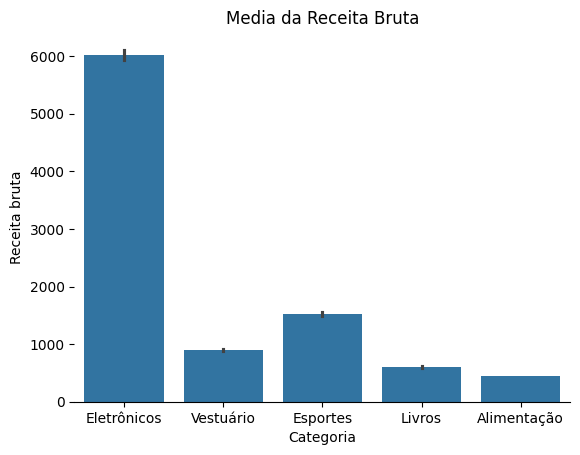

In [1100]:
sns.barplot(data= df,x='categoria',y="receita_bruta")
sns.despine(left = True)
plt.title('Media da Receita Bruta')
plt.xlabel('Categoria')
plt.ylabel('Receita bruta')

## B) Gráfico de Linha

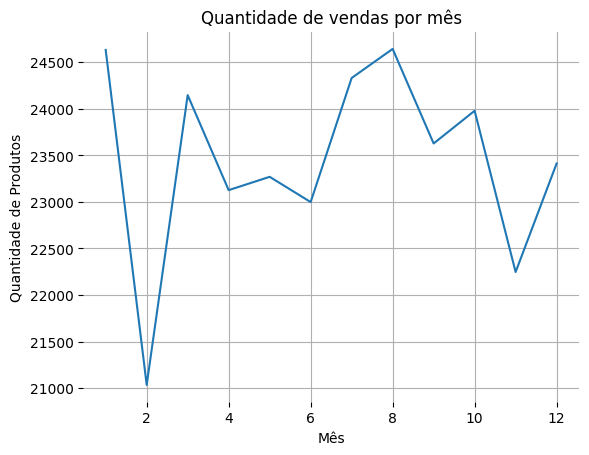

In [1101]:
sns.lineplot(data= df, x='mes', y='quantidade',estimator='sum', errorbar=None)
sns.despine(bottom=True, left=True)
plt.title('Quantidade de vendas por mês')
plt.xlabel('Mês')
plt.ylabel('Quantidade de Produtos')
plt.grid()


## C) Gráfico de dispersão

(0.0, 20.0)

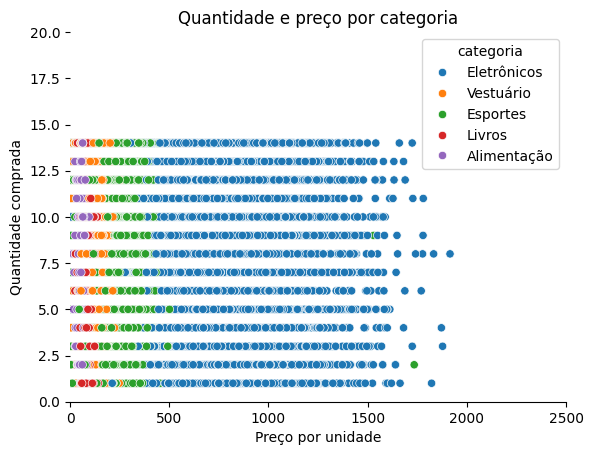

In [1102]:
sns.scatterplot(data=df, x='preco_unitario', y='quantidade', hue='categoria')
sns.despine(left=True)
plt.title('Quantidade e preço por categoria')
plt.xlabel('Preço por unidade')
plt.ylabel('Quantidade comprada')
plt.xlim(0,2500)
plt.ylim(0,20)

## D) Mapa de calor

Text(0.5, 1.0, 'Correlação')

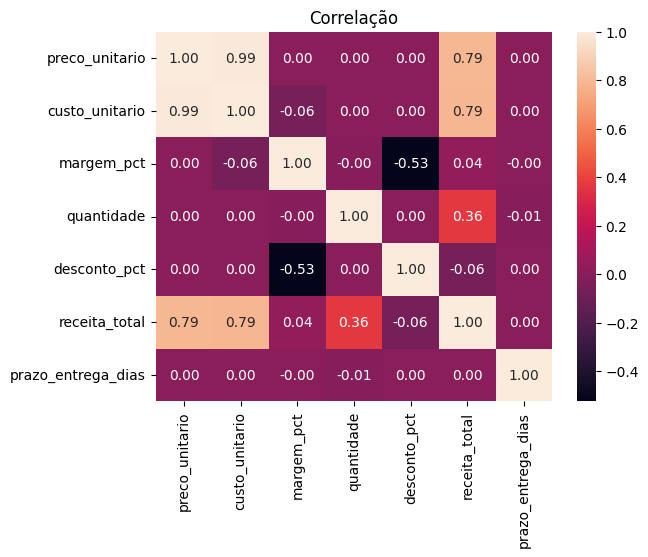

In [ ]:
numeros = ['preco_unitario',
'custo_unitario',      
'margem_pct',
'quantidade',      
'desconto_pct',  
'receita_total',                          
'prazo_entrega_dias']
correlacao = df[numeros].corr()
sns.heatmap(data= correlacao, annot=True, fmt='.2f')
sns.despine(left=True, bottom=True)
plt.title('Correlação')